<a href="https://colab.research.google.com/github/KaveeshaHeshan/R26-IT-120/blob/Perera-C-.-A--ML/model/rubber_isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving final_dataset_1000.csv to final_dataset_1000.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, accuracy_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [3]:
df = pd.read_csv('final_dataset_1000.csv')

print(f"✅ Dataset loaded!")
print(f"📊 Shape: {df.shape}")
print(f"\n📋 Columns: {df.columns.tolist()}")
df.head(3)

✅ Dataset loaded!
📊 Shape: (1001, 19)

📋 Columns: ['sample_id', 'collection_date', 'farmer_id', 'batch_number', 'lab_technician', 'weather_condition', 'truck_number', 'collection_shift', 'pH', 'pH_duplicate', 'turbidity_ntu', 'turbidity_log', 'temperature_c', 'ammonia_content', 'color_score', 'vfa', 'drc', 'grade', 'adulteration_type']


,sample_id,collection_date,farmer_id,batch_number,lab_technician,weather_condition,truck_number,collection_shift,pH,pH_duplicate,turbidity_ntu,turbidity_log,temperature_c,ammonia_content,color_score,vfa,drc,grade,adulteration_type
0,LAT_03110,9/27/2024,F003,BATCH_2742,TECH_05,Rainy,WP_8405,Morning,5.787,5.7842,110.88,4.7084,28.48,0.164,4,0.078,59.34,B,NaN
1,ADU_STARCH_030,3/10/2026,F_SIM,BATCH_ST_030,TECH_SIM,Sunny,WP_SIM,Morning,6.228,6.0720,254.80,0.0000,29.71,0.221,4,0.048,58.26,ABNORMAL,Starch_Addition
2,LAT_02110,2/3/2022,F007,BATCH_6552,TECH_04,Windy,WP_4300,Afternoon,5.431,5.4332,146.84,4.9893,31.42,0.141,5,0.096,58.90,C,NaN


In [4]:
# Label: NaN = Normal(0), others = Abnormal(1)
df['label'] = df['adulteration_type'].apply(
    lambda x: 1 if pd.notna(x) else 0
)

# Engineered features
df['ph_consistency']      = abs(df['pH'] - df['pH_duplicate'])
df['ammonia_vfa_product'] = df['ammonia_content'] * df['vfa']

# Outlier capping
cap_features = ['pH', 'turbidity_ntu', 'temperature_c',
                'ammonia_content', 'vfa']
for col in cap_features:
    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p1, upper=p99)

# Final features (no DRC)
FEATURES = ['pH', 'turbidity_ntu', 'temperature_c', 'ammonia_content',
            'vfa', 'ph_consistency', 'ammonia_vfa_product']

X = df[FEATURES]
y = df['label']

print("✅ Feature Engineering done!")
print(f"\n📋 Features ({len(FEATURES)}):")
for i, f in enumerate(FEATURES, 1):
    print(f"   {i}. {f}")
print(f"\n✅ Normal    : {(y==0).sum()} samples")
print(f"⚠️  Abnormal : {(y==1).sum()} samples")

✅ Feature Engineering done!

📋 Features (7):
   1. pH
   2. turbidity_ntu
   3. temperature_c
   4. ammonia_content
   5. vfa
   6. ph_consistency
   7. ammonia_vfa_product

✅ Normal    : 801 samples
⚠️  Abnormal : 200 samples


In [5]:
# Train/Test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Normal samples only for training
X_train_normal = X_train_scaled[y_train == 0]

print("✅ Split & Scaling done!")
print(f"\n📊 Train set : {X_train.shape[0]} samples")
print(f"   ✅ Normal  : {(y_train==0).sum()}")
print(f"   ⚠️  Abnormal: {(y_train==1).sum()}")
print(f"\n📊 Test set  : {X_test.shape[0]} samples")
print(f"   ✅ Normal  : {(y_test==0).sum()}")
print(f"   ⚠️  Abnormal: {(y_test==1).sum()}")
print(f"\n🎯 Training on: {X_train_normal.shape[0]} NORMAL samples only!")

✅ Split & Scaling done!

📊 Train set : 800 samples
   ✅ Normal  : 640
   ⚠️  Abnormal: 160

📊 Test set  : 201 samples
   ✅ Normal  : 161
   ⚠️  Abnormal: 40

🎯 Training on: 640 NORMAL samples only!


In [6]:
# Train model on NORMAL samples only
model = IsolationForest(
    contamination=0.2,
    n_estimators=200,
    random_state=42
)
model.fit(X_train_normal)

# Predict on test set
predictions_raw = model.predict(X_test_scaled)
y_pred = np.array([1 if p == -1 else 0 for p in predictions_raw])

# Anomaly scores
scores = model.decision_function(X_test_scaled)
y_scores = -scores  # higher = more abnormal

print("✅ Isolation Forest trained!")
print(f"\n📊 Test Predictions:")
print(f"   ✅ Predicted Normal  : {(y_pred==0).sum()}")
print(f"   ⚠️  Predicted Abnormal: {(y_pred==1).sum()}")

✅ Isolation Forest trained!

📊 Test Predictions:
   ✅ Predicted Normal  : 130
   ⚠️  Predicted Abnormal: 71


In [7]:
# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_scores)

print("=" * 50)
print("📊 ISOLATION FOREST - RESULTS")
print("=" * 50)
print(f"  ✅ Accuracy  : {acc*100:.2f}%")
print(f"  ✅ Precision : {prec*100:.2f}%")
print(f"  ✅ Recall    : {rec*100:.2f}%")
print(f"  ✅ F1 Score  : {f1*100:.2f}%")
print(f"  ✅ AUC-ROC   : {auc*100:.2f}%")
print("=" * 50)
print()
print("📋 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Abnormal']))

📊 ISOLATION FOREST - RESULTS
  ✅ Accuracy  : 84.58%
  ✅ Precision : 56.34%
  ✅ Recall    : 100.00%
  ✅ F1 Score  : 72.07%
  ✅ AUC-ROC   : 100.00%

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.81      0.89       161
    Abnormal       0.56      1.00      0.72        40

    accuracy                           0.85       201
   macro avg       0.78      0.90      0.81       201
weighted avg       0.91      0.85      0.86       201



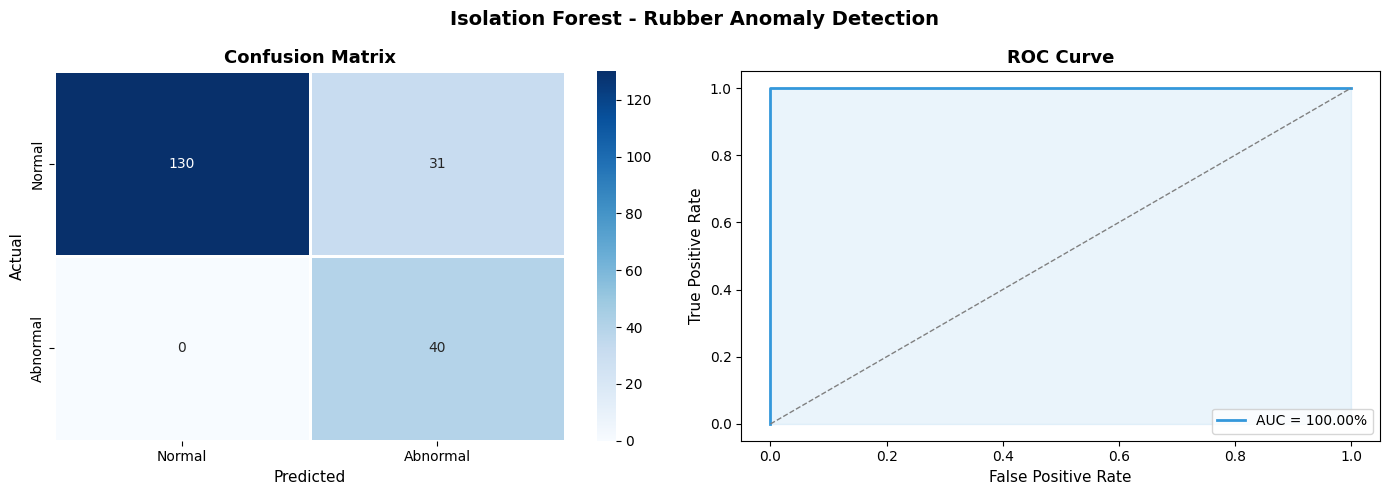

✅ Graphs saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'],
            ax=axes[0], linewidths=2)
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)

# Graph 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
axes[1].plot(fpr, tpr, color='#3498db', lw=2,
             label=f'AUC = {auc*100:.2f}%')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].legend(loc='lower right')

plt.suptitle('Isolation Forest - Rubber Anomaly Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphs saved!')

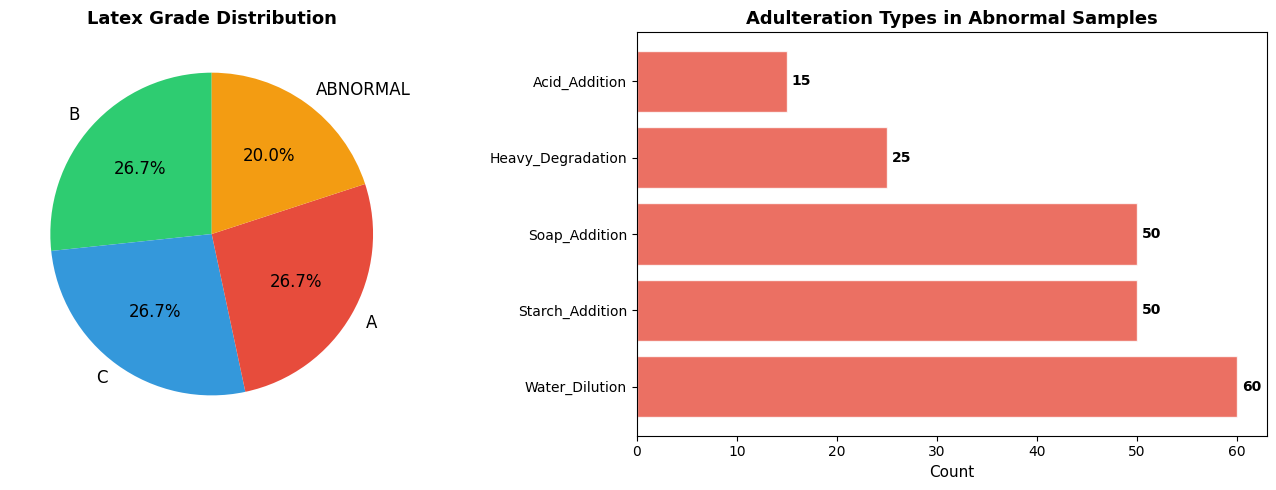

✅ Chart 1 saved!


In [9]:
#Grade & Adulteration Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Grade Distribution Pie Chart
grade_counts = df['grade'].value_counts()
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
axes[0].pie(grade_counts, labels=grade_counts.index,
            autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Latex Grade Distribution',
                  fontweight='bold', fontsize=13)

# Graph 2: Adulteration Types Bar Chart
adu_counts = df['adulteration_type'].value_counts()
bars = axes[1].barh(adu_counts.index, adu_counts.values,
                    color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_title('Adulteration Types in Abnormal Samples',
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel('Count', fontsize=11)
for bar, val in zip(bars, adu_counts.values):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() +
                 bar.get_height()/2, str(val),
                 va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_01_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved!')

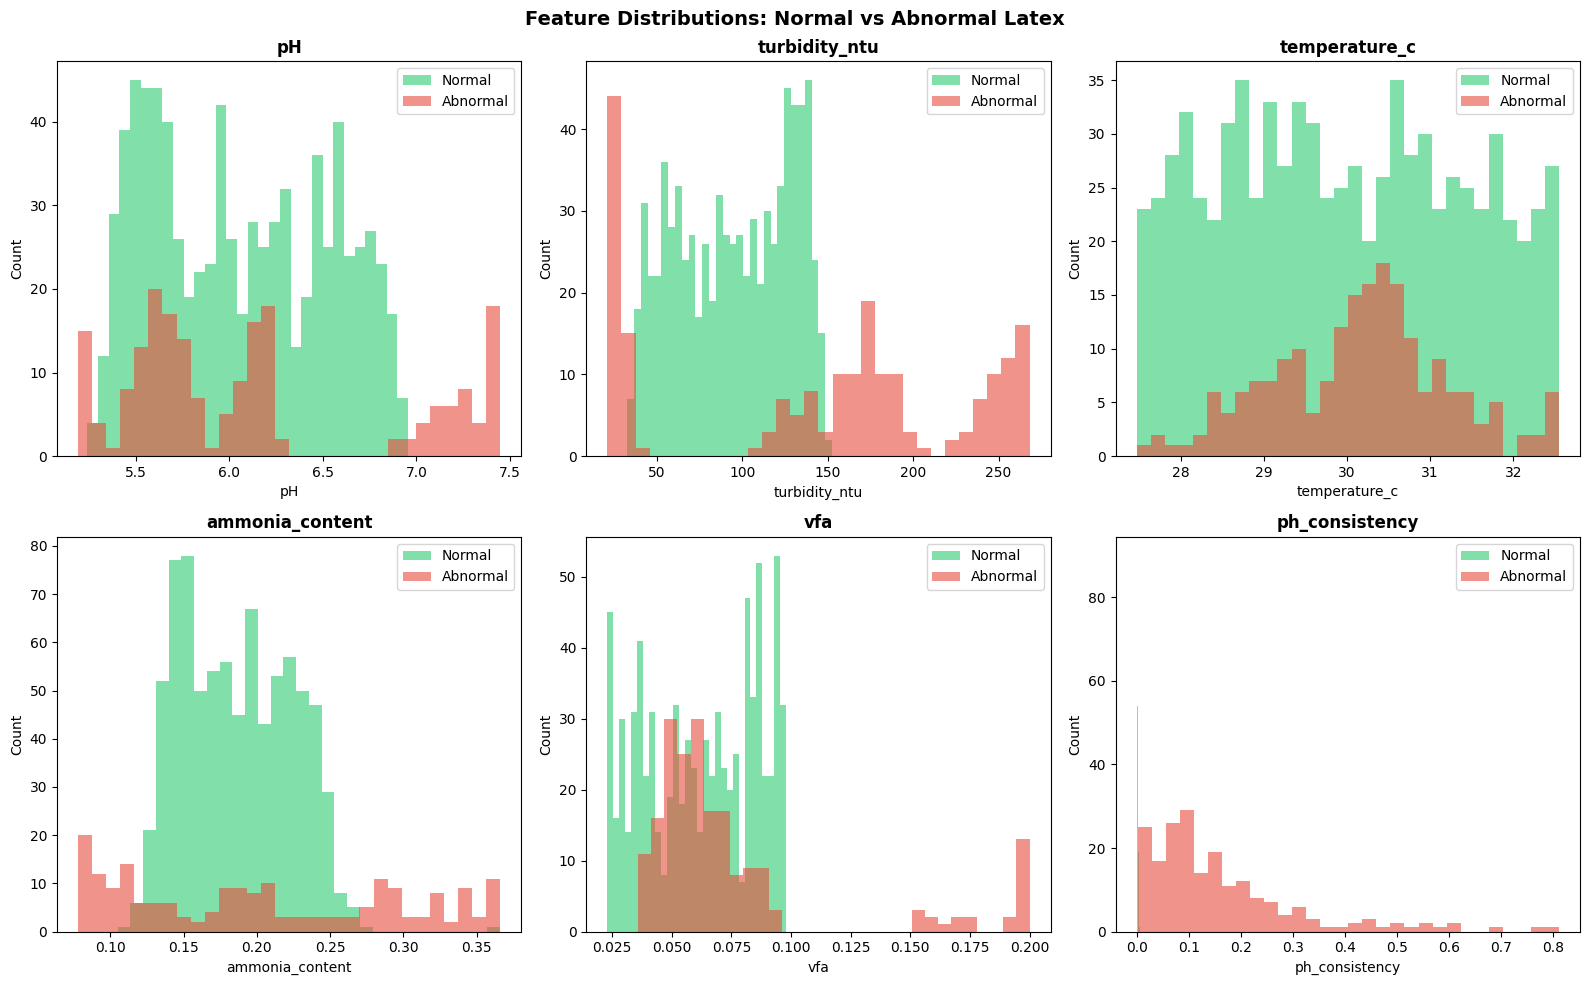

✅ Chart 2 saved!


In [10]:
#Normal vs Abnormal Feature Comparison
COMPARE = ['pH', 'turbidity_ntu', 'temperature_c',
           'ammonia_content', 'vfa', 'ph_consistency']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

normal_data   = df[df['label'] == 0]
abnormal_data = df[df['label'] == 1]

for i, feature in enumerate(COMPARE):
    axes[i].hist(normal_data[feature], bins=30,
                 alpha=0.6, color='#2ecc71', label='Normal')
    axes[i].hist(abnormal_data[feature], bins=30,
                 alpha=0.6, color='#e74c3c', label='Abnormal')
    axes[i].set_title(f'{feature}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].legend()

plt.suptitle('Feature Distributions: Normal vs Abnormal Latex',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_02_feature_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved!')

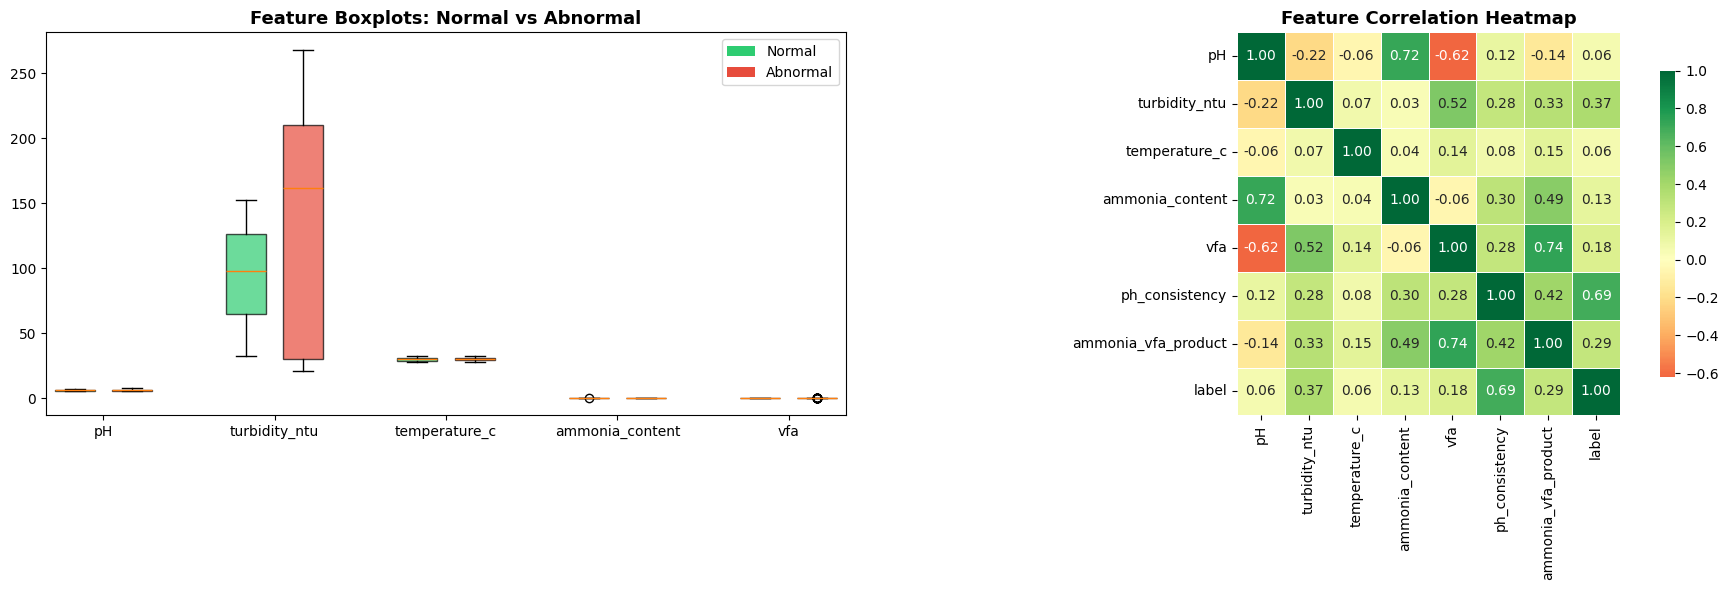

✅ Chart 3 saved!


In [11]:
#Boxplots & Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graph 1: Boxplots
BOX_FEATURES = ['pH', 'turbidity_ntu', 'temperature_c',
                'ammonia_content', 'vfa']
box_data = [
    [df[df['label']==0][f].values,
     df[df['label']==1][f].values]
    for f in BOX_FEATURES
]

positions = []
data_all  = []
colors_bp = []
for i, (norm, abn) in enumerate(box_data):
    positions.extend([i*3+1, i*3+2])
    data_all.extend([norm, abn])
    colors_bp.extend(['#2ecc71', '#e74c3c'])

bp = axes[0].boxplot(data_all, positions=positions,
                     patch_artist=True, widths=0.7)
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_xticks([i*3+1.5 for i in range(len(BOX_FEATURES))])
axes[0].set_xticklabels(BOX_FEATURES, fontsize=10)
axes[0].set_title('Feature Boxplots: Normal vs Abnormal',
                  fontweight='bold', fontsize=13)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Normal'),
                   Patch(facecolor='#e74c3c', label='Abnormal')]
axes[0].legend(handles=legend_elements)

# Graph 2: Correlation Heatmap
CORR_FEATURES = ['pH', 'turbidity_ntu', 'temperature_c',
                 'ammonia_content', 'vfa',
                 'ph_consistency', 'ammonia_vfa_product', 'label']
corr = df[CORR_FEATURES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Feature Correlation Heatmap',
                  fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('viz_03_boxplot_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved!')

In [12]:
# Check dataset value
print("=== Normal Latex Value Ranges ===")
normal_df = df[df['label']==0]
for feature in FEATURES:
    print(f"{feature}:")
    print(f"  Min:  {normal_df[feature].min():.3f}")
    print(f"  Max:  {normal_df[feature].max():.3f}")
    print(f"  Mean: {normal_df[feature].mean():.3f}")
    print()

=== Normal Latex Value Ranges ===
pH:
  Min:  5.240
  Max:  6.956
  Mean: 6.054

turbidity_ntu:
  Min:  32.650
  Max:  152.620
  Mean: 95.449

temperature_c:
  Min:  27.470
  Max:  32.550
  Mean: 29.956

ammonia_content:
  Min:  0.105
  Max:  0.366
  Mean: 0.186

vfa:
  Min:  0.023
  Max:  0.098
  Mean: 0.062

ph_consistency:
  Min:  0.000
  Max:  0.006
  Mean: 0.002

ammonia_vfa_product:
  Min:  0.005
  Max:  0.147
  Mean: 0.011



In [13]:
# Real-time Test
def predict_latex(pH, turbidity, temperature, ammonia, vfa, pH_duplicate=None):
    import pandas as pd

    # Engineered features calculate කරනවා
    if pH_duplicate is None:
        pH_duplicate = pH  # same value දුන්නොත් ph_consistency = 0

    ph_consistency      = abs(pH - pH_duplicate)
    ammonia_vfa_product = ammonia * vfa

    sample = pd.DataFrame(
        [[pH, turbidity, temperature, ammonia, vfa,
          ph_consistency, ammonia_vfa_product]],
        columns=FEATURES
    )

    sample_scaled = scaler.transform(sample)
    prediction    = model.predict(sample_scaled)
    score         = model.decision_function(sample_scaled)[0]
    result        = "ABNORMAL 🚨" if prediction[0] == -1 else "NORMAL ✅"

    print(f"Result: {result} | Score: {score:.4f}")
    return result

print("=== Normal Latex ===")
predict_latex(6.0, 95.0, 30.0, 0.186, 0.062)

print("\n=== Water Dilution ===")
predict_latex(7.8, 280.0, 29.0, 0.08, 0.12)

print("\n=== Soap Addition ===")
predict_latex(9.2, 320.0, 28.0, 0.45, 0.35)

print("\n=== Acid Addition ===")
predict_latex(4.5, 150.0, 31.0, 0.12, 0.18)

=== Normal Latex ===
Result: NORMAL ✅ | Score: 0.0309

=== Water Dilution ===
Result: ABNORMAL 🚨 | Score: -0.1403

=== Soap Addition ===
Result: ABNORMAL 🚨 | Score: -0.1503

=== Acid Addition ===
Result: ABNORMAL 🚨 | Score: -0.1119


'ABNORMAL 🚨'

In [14]:
import joblib

# Model save
joblib.dump(model, 'isolation_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved! ✅")
print("Files: isolation_forest_model.pkl, scaler.pkl")

Model saved! ✅
Files: isolation_forest_model.pkl, scaler.pkl


In [ ]:
from google.colab import files

# Download model files
files.download('isolation_forest_model.pkl')
files.download('scaler.pkl')

print("Download started! ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! ✅
